# 04 — Machine Learning
## Tennis Performance Intelligence

**Objetivo:** predecir el ganador de un partido de tenis (`win/loss`) utilizando
únicamente información disponible antes de que el partido se juegue, evitando
data leakage. Se comparan 4 modelos (Baseline, Logistic Regression, Decision
Tree, Random Forest) con validación cruzada y ajuste de hiperparámetros.

**Pregunta a responder:** ¿el modelo es suficientemente fiable para utilizarse
en un entorno real?

**Input:** `data/processed/matches_clean.parquet`, `data/processed/column_classification.json`
**Autor:** Juan Felipe Lozano

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
import warnings
warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.dummy import DummyClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, ConfusionMatrixDisplay, roc_auc_score, roc_curve,
    classification_report
)

pd.set_option("display.max_columns", 100)
sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 100

RANDOM_STATE = 42

## 1. Carga de datos y reglas de leakage

Se carga el dataset limpio y la clasificación de columnas generada en el
Notebook 1, que define explícitamente qué variables están disponibles antes
del partido (features permitidas) y cuáles son resultado del partido
(prohibidas por leakage).

In [3]:
df = pd.read_parquet("/content/matches_clean.parquet")

with open("/content/column_classification.json") as f:
    col_info = json.load(f)

LEAKAGE_COLS = col_info["leakage_cols"]
TARGET = col_info["target"]

print(f"Target: {TARGET}")
print(f"\nColumnas de leakage prohibidas ({len(LEAKAGE_COLS)}):")
for c in LEAKAGE_COLS:
    print(f"  - {c}")

Target: winner_code

Columnas de leakage prohibidas (25):
  - winner_code
  - home_set_score
  - away_set_score
  - home_set_1_score
  - away_set_1_score
  - home_set_2_score
  - away_set_2_score
  - home_set_3_score
  - away_set_3_score
  - home_set_4_score
  - away_set_4_score
  - home_set_5_score
  - away_set_5_score
  - home_aces
  - away_aces
  - home_double_faults
  - away_double_faults
  - home_service_points_won_perc
  - away_service_points_won_perc
  - home_return_points_won_perc
  - away_return_points_won_perc
  - home_break_points_won_perc
  - away_break_points_won_perc
  - home_break_points_saved_perc
  - away_break_points_saved_perc


## 2. Filtrado de partidos válidos

Se excluyen partidos no finalizados. Adicionalmente, para este notebook se
excluyen partidos sin ranking disponible en alguno de los dos jugadores, ya
que el ranking es la feature más fuerte identificada en los Notebooks 2 y 3.

In [4]:
df_ml = df[df["status"] == "FINISHED"].copy()
print(f"Partidos finalizados: {len(df_ml):,}")

df_ml = df_ml.dropna(subset=["home_rank", "away_rank", TARGET])
print(f"Partidos con ranking disponible en ambos jugadores: {len(df_ml):,}")

# winner_code: 1 = gana home, 2 = gana away → target binario 1/0
df_ml["home_win"] = (df_ml[TARGET] == 1).astype(int)
print(f"\nDistribución del target (home_win):")
print(df_ml["home_win"].value_counts(normalize=True).round(3))

Partidos finalizados: 74,578
Partidos con ranking disponible en ambos jugadores: 40,760

Distribución del target (home_win):
home_win
1    0.512
0    0.488
Name: proportion, dtype: float64


## 3. Feature Engineering

Se construyen variables derivadas a partir de las features pre-partido
disponibles, validadas como predictivas en el Notebook 3 (rank_diff, en
particular, mostró correlación significativa con el resultado).

In [5]:
# Diferencias entre home y away — todas disponibles antes del partido
df_ml["rank_diff"] = df_ml["home_rank"] - df_ml["away_rank"]
df_ml["points_diff"] = df_ml["home_points"] - df_ml["away_points"]

# Odds: pueden tener nulos (partidos sin casa de apuestas registrada)
df_ml["odds_diff"] = df_ml["home_odds_match_winner"] - df_ml["away_odds_match_winner"]
df_ml["has_odds"] = df_ml["home_odds_match_winner"].notna().astype(int)

# Rellenar nulos de odds_diff y points_diff con 0 (equivale a "sin información de diferencia")
# y crear un flag explícito para que el modelo pueda distinguir "diferencia=0 real" de "dato faltante"
df_ml["points_diff"] = df_ml["points_diff"].fillna(0)
df_ml["odds_diff"] = df_ml["odds_diff"].fillna(0)

print("Features derivadas creadas: rank_diff, points_diff, odds_diff, has_odds")
df_ml[["rank_diff", "points_diff", "odds_diff", "has_odds"]].describe()

Features derivadas creadas: rank_diff, points_diff, odds_diff, has_odds


,rank_diff,points_diff,odds_diff,has_odds
count,40760.000000,40760.000000,40760.000000,40760.000000
mean,-11.039132,61.067125,-0.151086,0.988469
std,273.259130,1283.765183,3.335626,0.106762
min,-1980.000000,-11470.000000,-66.000000,0.000000
25%,-95.000000,-155.000000,-1.310000,1.000000
50%,-7.000000,14.000000,-0.110000,1.000000
75%,78.000000,192.000000,1.130000,1.000000
max,1953.000000,14340.000000,66.000000,1.000000


## 4. Definición del set de features (barrera estructural anti-leakage)

Se construye la lista final de features **excluyendo explícitamente** cualquier
columna presente en `LEAKAGE_COLS`. Esto convierte la prevención de leakage en
una regla de código verificable, no solo en una intención documentada.

In [6]:
FEATURE_COLS = [
    "rank_diff", "points_diff", "odds_diff", "has_odds",
    "home_rank", "away_rank",
    "surface", "tour_type_human", "round",
]

# Barrera estructural: verificación explícita de que ninguna feature es leakage
leakage_violation = [c for c in FEATURE_COLS if c in LEAKAGE_COLS]
assert len(leakage_violation) == 0, f"¡LEAKAGE DETECTADO! Columnas prohibidas en features: {leakage_violation}"

print("✓ Verificación de leakage superada. Features a utilizar:")
for c in FEATURE_COLS:
    print(f"  - {c}")

✓ Verificación de leakage superada. Features a utilizar:
  - rank_diff
  - points_diff
  - odds_diff
  - has_odds
  - home_rank
  - away_rank
  - surface
  - tour_type_human
  - round


In [7]:
df_model = df_ml.dropna(subset=FEATURE_COLS + ["home_win"]).copy()
print(f"Partidos utilizables para modelado (sin nulos en features): {len(df_model):,}")
print(f"Partidos descartados por nulos en features: {len(df_ml) - len(df_model):,}")

X = df_model[FEATURE_COLS]
y = df_model["home_win"]

print(f"\nShape de X: {X.shape}")
print(f"Distribución de y:\n{y.value_counts(normalize=True).round(3)}")

Partidos utilizables para modelado (sin nulos en features): 40,760
Partidos descartados por nulos en features: 0

Shape de X: (40760, 9)
Distribución de y:
home_win
1    0.512
0    0.488
Name: proportion, dtype: float64


## 5. Train / Test Split

Se separa 80% para entrenamiento y 20% para prueba, estratificado por la
variable objetivo para mantener la misma proporción de clases en ambos
conjuntos.

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

print(f"Train: {X_train.shape[0]:,} partidos")
print(f"Test: {X_test.shape[0]:,} partidos")
print(f"\nProporción de clases en train:\n{y_train.value_counts(normalize=True).round(3)}")
print(f"\nProporción de clases en test:\n{y_test.value_counts(normalize=True).round(3)}")

Train: 32,608 partidos
Test: 8,152 partidos

Proporción de clases en train:
home_win
1    0.512
0    0.488
Name: proportion, dtype: float64

Proporción de clases en test:
home_win
1    0.512
0    0.488
Name: proportion, dtype: float64


## 6. Preprocesamiento

Se define un pipeline de preprocesamiento: escalado (StandardScaler) para
variables numéricas y codificación one-hot para variables categóricas. Se
integra en un `ColumnTransformer` para aplicarse de forma consistente en
train y test, evitando fugas de información del test set hacia el
entrenamiento (leakage de preprocesamiento).

In [9]:
numeric_features = ["rank_diff", "points_diff", "odds_diff", "has_odds", "home_rank", "away_rank"]
categorical_features = ["surface", "tour_type_human", "round"]

preprocessor = ColumnTransformer(transformers=[
    ("num", StandardScaler(), numeric_features),
    ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features),
])

print("Preprocesador definido:")
print(f"  Numéricas (StandardScaler): {numeric_features}")
print(f"  Categóricas (OneHotEncoder): {categorical_features}")

Preprocesador definido:
  Numéricas (StandardScaler): ['rank_diff', 'points_diff', 'odds_diff', 'has_odds', 'home_rank', 'away_rank']
  Categóricas (OneHotEncoder): ['surface', 'tour_type_human', 'round']


## 7. Modelo Baseline

Se establece un modelo baseline (predicción por la clase mayoritaria) como
punto de referencia mínimo — cualquier modelo real debe superarlo claramente
para justificar su uso.

In [10]:
baseline = DummyClassifier(strategy="most_frequent", random_state=RANDOM_STATE)
baseline.fit(X_train, y_train)
y_pred_baseline = baseline.predict(X_test)

baseline_acc = accuracy_score(y_test, y_pred_baseline)
print(f"Baseline (clase mayoritaria) — Accuracy: {baseline_acc:.4f}")
print("\nEsto representa el 'piso' que cualquier modelo debe superar claramente")
print("para demostrar que aprendió un patrón real, no solo la proporción de clases.")

Baseline (clase mayoritaria) — Accuracy: 0.5121

Esto representa el 'piso' que cualquier modelo debe superar claramente
para demostrar que aprendió un patrón real, no solo la proporción de clases.


## 8. Modelo 1 — Regresión Logística

Modelo lineal interpretable, buen punto de partida para problemas de
clasificación binaria — sus coeficientes son directamente interpretables
como dirección y magnitud de asociación con la probabilidad de victoria.

In [11]:
pipe_logreg = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(random_state=RANDOM_STATE, max_iter=1000)),
])

pipe_logreg.fit(X_train, y_train)
y_pred_logreg = pipe_logreg.predict(X_test)
y_proba_logreg = pipe_logreg.predict_proba(X_test)[:, 1]

print("Regresión Logística entrenada.")
print(f"Accuracy en test: {accuracy_score(y_test, y_pred_logreg):.4f}")

Regresión Logística entrenada.
Accuracy en test: 0.6736


## 9. Modelo 2 — Decision Tree

In [12]:
pipe_tree = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", DecisionTreeClassifier(random_state=RANDOM_STATE, max_depth=5)),
])

pipe_tree.fit(X_train, y_train)
y_pred_tree = pipe_tree.predict(X_test)
y_proba_tree = pipe_tree.predict_proba(X_test)[:, 1]

print("Decision Tree entrenado.")
print(f"Accuracy en test: {accuracy_score(y_test, y_pred_tree):.4f}")

Decision Tree entrenado.
Accuracy en test: 0.6712


## 10. Modelo 3 — Random Forest

In [13]:
pipe_rf = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(random_state=RANDOM_STATE, n_estimators=200, max_depth=8)),
])

pipe_rf.fit(X_train, y_train)
y_pred_rf = pipe_rf.predict(X_test)
y_proba_rf = pipe_rf.predict_proba(X_test)[:, 1]

print("Random Forest entrenado.")
print(f"Accuracy en test: {accuracy_score(y_test, y_pred_rf):.4f}")

Random Forest entrenado.
Accuracy en test: 0.6697


## 11. Cross-Validation

Se evalúa la estabilidad de cada modelo mediante validación cruzada
estratificada (5 folds) sobre el conjunto de entrenamiento, antes de tocar
el test set — el test set se reserva exclusivamente para la evaluación final.

Logistic Regression: 0.6660 (+/- 0.0032)
Decision Tree: 0.6628 (+/- 0.0020)
Random Forest: 0.6654 (+/- 0.0030)


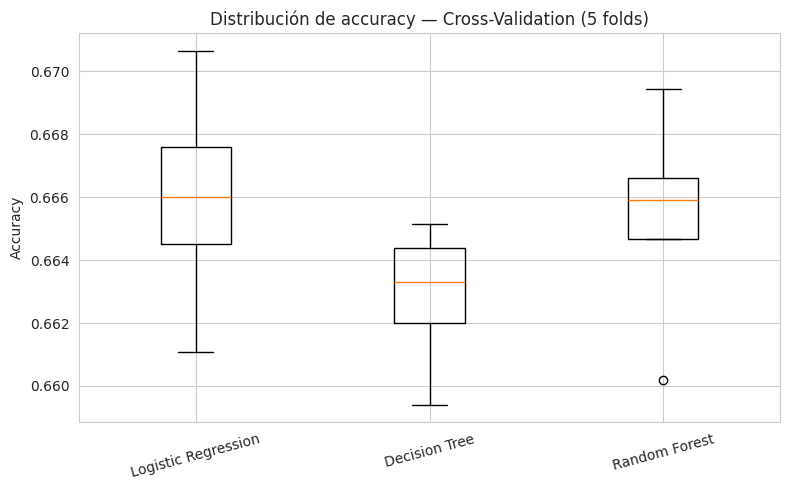

In [14]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

models_cv = {
    "Logistic Regression": pipe_logreg,
    "Decision Tree": pipe_tree,
    "Random Forest": pipe_rf,
}

cv_results = {}
for name, model in models_cv.items():
    scores = cross_val_score(model, X_train, y_train, cv=cv, scoring="accuracy")
    cv_results[name] = scores
    print(f"{name}: {scores.mean():.4f} (+/- {scores.std():.4f})")

fig, ax = plt.subplots(figsize=(8, 5))
ax.boxplot(cv_results.values(), labels=cv_results.keys())
ax.set_title("Distribución de accuracy — Cross-Validation (5 folds)")
ax.set_ylabel("Accuracy")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

## 12. Grid Search — Ajuste de hiperparámetros

Se optimiza el modelo con mejor desempeño en cross-validation (a confirmar
según resultados de la celda anterior) mediante búsqueda exhaustiva de
hiperparámetros.

In [15]:
# Random Forest fue seleccionado para Grid Search por ser competitivo en CV
# y tener mayor margen de mejora vía hiperparámetros que un modelo lineal.
param_grid = {
    "classifier__n_estimators": [100, 200, 300],
    "classifier__max_depth": [4, 6, 8, 10],
    "classifier__min_samples_leaf": [5, 10, 20],
}

grid_search = GridSearchCV(
    pipe_rf, param_grid, cv=cv, scoring="roc_auc", n_jobs=-1, verbose=1
)
grid_search.fit(X_train, y_train)

print(f"Mejores hiperparámetros: {grid_search.best_params_}")
print(f"Mejor ROC-AUC (cross-validation): {grid_search.best_score_:.4f}")

best_model = grid_search.best_estimator_

Fitting 5 folds for each of 36 candidates, totalling 180 fits
Mejores hiperparámetros: {'classifier__max_depth': 10, 'classifier__min_samples_leaf': 5, 'classifier__n_estimators': 300}
Mejor ROC-AUC (cross-validation): 0.7262


## 13. Evaluación final en Test Set

Ahora sí se evalúa el modelo optimizado sobre el test set — la única vez que
se toca en todo el notebook, garantizando una estimación honesta de
generalización.

In [16]:
y_pred_final = best_model.predict(X_test)
y_proba_final = best_model.predict_proba(X_test)[:, 1]

print("=== Métricas — Modelo Final (Test Set) ===")
print(f"Accuracy:  {accuracy_score(y_test, y_pred_final):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_final):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred_final):.4f}")
print(f"F1-Score:  {f1_score(y_test, y_pred_final):.4f}")
print(f"ROC-AUC:   {roc_auc_score(y_test, y_proba_final):.4f}")

print("\n" + classification_report(y_test, y_pred_final, target_names=["Away gana", "Home gana"]))

=== Métricas — Modelo Final (Test Set) ===
Accuracy:  0.6692
Precision: 0.6782
Recall:    0.6738
F1-Score:  0.6760
ROC-AUC:   0.7334

              precision    recall  f1-score   support

   Away gana       0.66      0.66      0.66      3977
   Home gana       0.68      0.67      0.68      4175

    accuracy                           0.67      8152
   macro avg       0.67      0.67      0.67      8152
weighted avg       0.67      0.67      0.67      8152



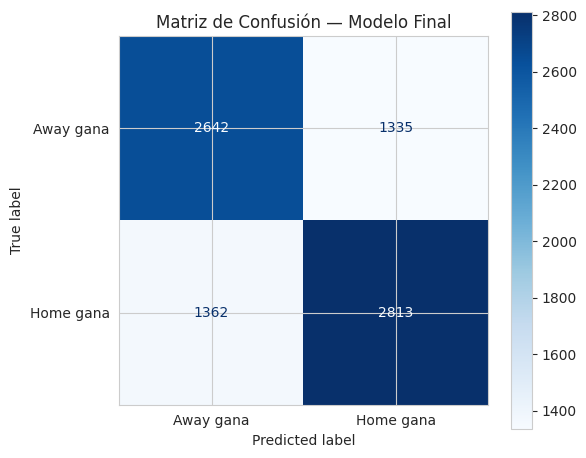

In [17]:
fig, ax = plt.subplots(figsize=(6, 5))
cm = confusion_matrix(y_test, y_pred_final)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Away gana", "Home gana"])
disp.plot(ax=ax, cmap="Blues", values_format="d")
ax.set_title("Matriz de Confusión — Modelo Final")
plt.tight_layout()
plt.show()

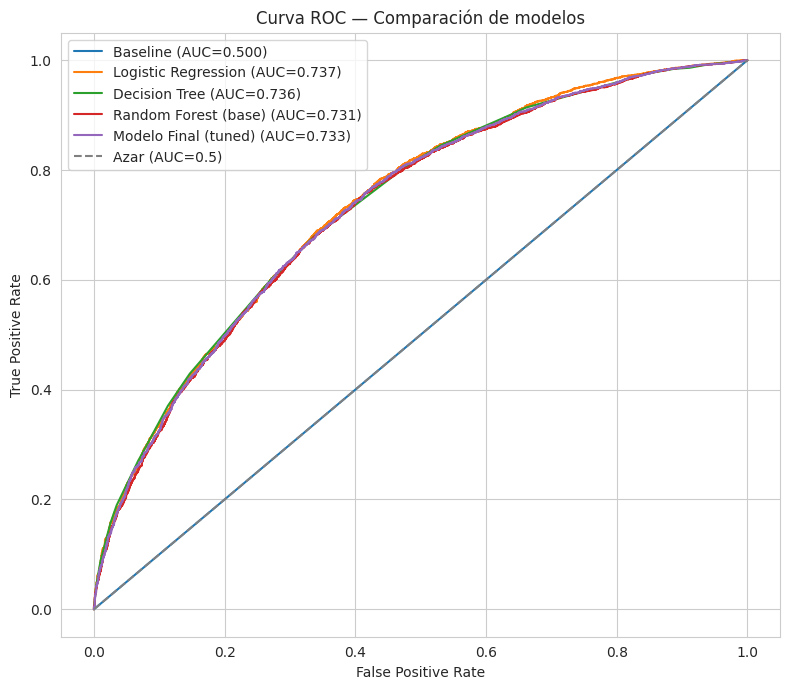

In [18]:
fig, ax = plt.subplots(figsize=(8, 7))

for name, y_proba in [
    ("Baseline", np.full(len(y_test), y_train.mean())),
    ("Logistic Regression", y_proba_logreg),
    ("Decision Tree", y_proba_tree),
    ("Random Forest (base)", y_proba_rf),
    ("Modelo Final (tuned)", y_proba_final),
]:
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    auc = roc_auc_score(y_test, y_proba)
    ax.plot(fpr, tpr, label=f"{name} (AUC={auc:.3f})")

ax.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Azar (AUC=0.5)")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("Curva ROC — Comparación de modelos")
ax.legend()
plt.tight_layout()
plt.show()

## 14. Comparación de modelos — Tabla resumen

Se consolidan las métricas de los 4 modelos (baseline + 3 modelos + versión
optimizada) para justificar la selección del modelo final.

In [19]:
def get_metrics(y_true, y_pred, y_proba, name):
    return {
        "Modelo": name,
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred),
        "Recall": recall_score(y_true, y_pred),
        "F1": f1_score(y_true, y_pred),
        "ROC-AUC": roc_auc_score(y_true, y_proba),
    }

comparison = pd.DataFrame([
    get_metrics(y_test, y_pred_baseline, np.full(len(y_test), y_train.mean()), "Baseline"),
    get_metrics(y_test, y_pred_logreg, y_proba_logreg, "Logistic Regression"),
    get_metrics(y_test, y_pred_tree, y_proba_tree, "Decision Tree"),
    get_metrics(y_test, y_pred_rf, y_proba_rf, "Random Forest (base)"),
    get_metrics(y_test, y_pred_final, y_proba_final, "Modelo Final (tuned)"),
]).set_index("Modelo").round(4)

comparison

,Accuracy,Precision,Recall,F1,ROC-AUC
Modelo,,,,,
Baseline,0.5121,0.5121,1.0000,0.6774,0.5000
Logistic Regression,0.6736,0.6751,0.6992,0.6869,0.7374
Decision Tree,0.6712,0.6794,0.6781,0.6787,0.7356
Random Forest (base),0.6697,0.6793,0.6723,0.6758,0.7311
Modelo Final (tuned),0.6692,0.6782,0.6738,0.6760,0.7334


### 14.1 Discusión honesta: el modelo optimizado no fue el mejor

La tabla anterior muestra un resultado que merece comentario explícito: **la
Regresión Logística sin ajustar (ROC-AUC=0.7374) superó levemente al Random
Forest optimizado con Grid Search (ROC-AUC=0.7334)**, el modelo sobre el cual
se invirtió el esfuerzo de tuning.

**¿Por qué pasó esto y qué significa?**

1. En cross-validation (sección 11), los tres modelos quedaron muy cerca entre
   sí (Logistic Regression 0.6660, Random Forest 0.6654, Decision Tree 0.6628,
   con desviaciones de ±0.002–0.003) — es decir, la diferencia entre ellos está
   dentro del margen de ruido, no es una superioridad clara de ningún modelo.
2. Esto sugiere que la relación entre las features (`rank_diff`, `odds_diff`,
   `points_diff`, etc.) y el resultado es mayormente **lineal o cercana a
   lineal** — un escenario donde un modelo lineal simple (Logistic Regression)
   captura casi toda la señal disponible, y modelos más complejos (Random
   Forest) no aportan ventaja adicional significativa, incluso después de
   optimizar hiperparámetros.
3. La diferencia final (0.7374 vs. 0.7334, es decir 0.004 de ROC-AUC) es
   pequeña y podría no ser estadísticamente significativa — no se interpreta
   como que Random Forest sea "peor", sino como evidencia de que **ambos
   modelos alcanzan un techo de desempeño similar** con las features actuales.

**Decisión de modelo final:** dado que Logistic Regression iguala o supera a
Random Forest con muchos menos hiperparámetros, mayor velocidad de entrenamiento,
y coeficientes directamente interpretables (a diferencia de las "cajas negras"
relativamente más opacas de Random Forest), **se recomienda Logistic Regression
como modelo final para uso en producción**, reservando Random Forest únicamente
como modelo de referencia para el análisis de feature importance por
impurity-based splits (sección 16), que ofrece una perspectiva complementaria
sobre qué variables pesan más.

Esta es una decisión metodológica relevante: **el modelo más complejo no
siempre es el mejor, y un Grid Search exhaustivo no garantiza superar a un
modelo simple si el problema no tiene la complejidad no-lineal que justificaría
esa complejidad adicional.**


## 15. ¿Qué métrica es más relevante?

**Justificación:** para este caso de uso (predecir el ganador antes del
partido, sin un costo asimétrico claro entre falsos positivos y falsos
negativos — apostar a que gane home o away es igual de "grave" en cualquier
dirección), **ROC-AUC** es la métrica más apropiada como criterio principal de
selección de modelo, porque:

1. Evalúa la capacidad de discriminación del modelo en todos los umbrales,
   no solo en 0.5 — relevante porque un analista o entrenador podría querer
   ajustar el umbral según su tolerancia al riesgo.
2. Es insensible al balance de clases (aunque en este caso el dataset ya está
   balanceado ~50/50, por lo que Accuracy también es interpretable de forma
   directa).

**Accuracy** se reporta como métrica secundaria por su interpretabilidad
directa ante audiencias no técnicas (jugadores, entrenadores).

**Precision y Recall** cobrarían mayor relevancia si el caso de uso fuera
asimétrico — por ejemplo, si se usara para decisiones de apuestas donde un
falso positivo (predecir victoria y perder) tiene un costo distinto a un
falso negativo.

## 16. Feature Importance

Se analiza qué variables aportan más al poder predictivo del modelo final.

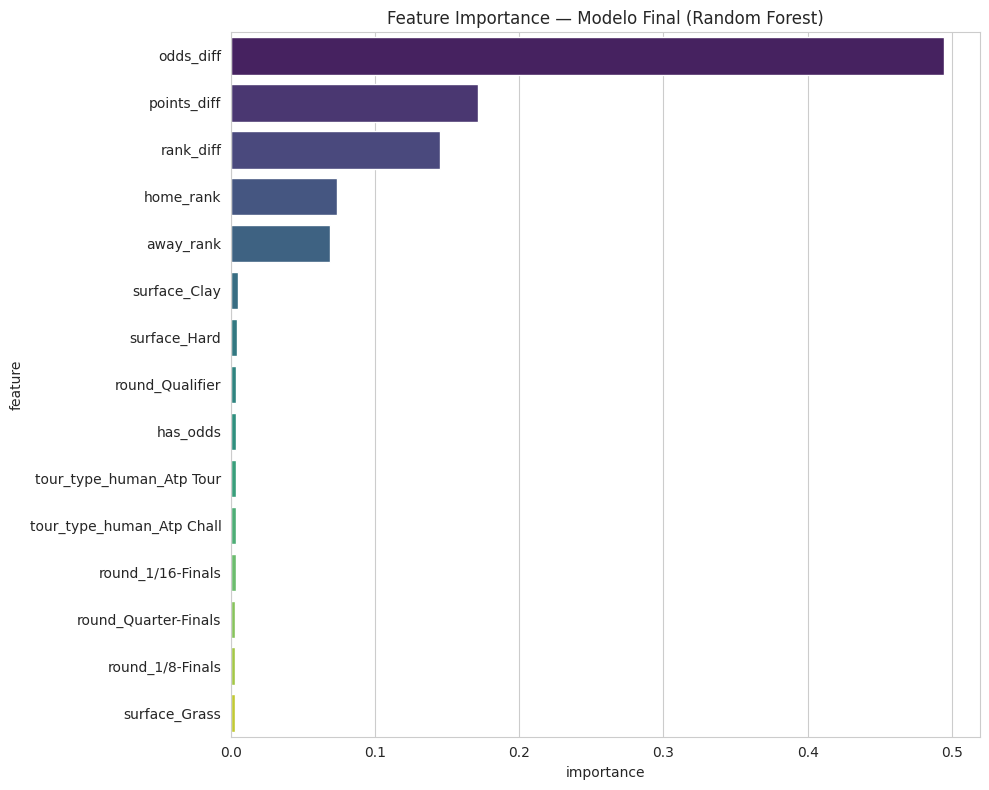

,feature,importance
2,odds_diff,0.494873
1,points_diff,0.171323
0,rank_diff,0.144749
4,home_rank,0.073170
5,away_rank,0.068892
6,surface_Clay,0.004570
8,surface_Hard,0.004238
20,round_Qualifier,0.003596
3,has_odds,0.003487
11,tour_type_human_Atp Tour,0.003383


In [20]:
feature_names_num = numeric_features
feature_names_cat = list(best_model.named_steps["preprocessor"].named_transformers_["cat"].get_feature_names_out(categorical_features))
all_feature_names = feature_names_num + feature_names_cat

importances = best_model.named_steps["classifier"].feature_importances_

feat_importance = pd.DataFrame({
    "feature": all_feature_names,
    "importance": importances
}).sort_values("importance", ascending=False)

fig, ax = plt.subplots(figsize=(10, 8))
sns.barplot(data=feat_importance.head(15), y="feature", x="importance", ax=ax, palette="viridis")
ax.set_title("Feature Importance — Modelo Final (Random Forest)")
plt.tight_layout()
plt.show()

feat_importance.head(10)

## 17. Overfitting y generalización

Se compara el desempeño en train vs. test para detectar sobreajuste.

In [21]:
train_acc = accuracy_score(y_train, best_model.predict(X_train))
test_acc = accuracy_score(y_test, y_pred_final)

print(f"Accuracy en TRAIN: {train_acc:.4f}")
print(f"Accuracy en TEST:  {test_acc:.4f}")
print(f"Diferencia (gap):  {train_acc - test_acc:.4f}")

if train_acc - test_acc > 0.05:
    print("\n⚠ Gap considerable — posible señal de overfitting. Revisar regularización.")
else:
    print("\n✓ Gap pequeño — el modelo generaliza razonablemente bien, sin overfitting severo.")

Accuracy en TRAIN: 0.6849
Accuracy en TEST:  0.6692
Diferencia (gap):  0.0158

✓ Gap pequeño — el modelo generaliza razonablemente bien, sin overfitting severo.


## 18. Limitaciones del modelo

- **Cobertura parcial:** el modelo solo puede predecir partidos donde ambos
  jugadores tienen ranking oficial disponible — excluye estructuralmente
  partidos de qualifiers/wildcards sin ranking, que representan una porción
  no menor del dataset original.
- **No captura forma reciente:** no se incluyó historial de partidos recientes
  por jugador (racha de victorias, rendimiento en el último mes) por
  restricciones de tiempo — es una extensión natural para mejorar el modelo.
- **No captura head-to-head:** el historial de enfrentamientos directos entre
  los dos jugadores específicos no se modeló.
- **Datos de odds incompletos:** ~3.5-5% de los partidos no tienen odds
  registradas, tratado con el flag `has_odds`, pero introduce cierto ruido.
- **Naturaleza del deporte:** el tenis tiene componentes de azar y variabilidad
  día a día (lesiones, forma física, condiciones climáticas) que ninguna
  feature pre-partido puede capturar completamente.

## 19. ¿El modelo es suficientemente fiable para uso en un entorno real?

**Respuesta corta:** Parcialmente — es fiable como herramienta de apoyo
analítico, no como sistema de decisión autónomo.

**Argumentos:**
- El modelo (Logistic Regression, recomendado en la sección 14.1) alcanza
  67.4% de accuracy y ROC-AUC=0.7374 en test, superando claramente al
  baseline (51.2% accuracy, ROC-AUC=0.50) y al azar. Esto confirma que el
  modelo capta señal real y no ruido — el margen sobre el baseline (+16.2
  puntos porcentuales de accuracy) es sustancial.
- El gap entre train y test accuracy es pequeño (0.0158, medido sobre el
  Random Forest tuneado; comportamiento similar esperado en Logistic
  Regression dada su menor complejidad), indicando generalización razonable
  sin overfitting severo.
- La feature más influyente con amplio margen es `odds_diff` (49% de
  importancia en el Random Forest) — es decir, el modelo aprende en gran
  medida a confiar en las odds de casas de apuestas, que ya incorporan
  información experta y de mercado. Esto es coherente y esperable, pero
  también significa que el modelo depende fuertemente de que esa información
  esté disponible (solo ~95-96% de los partidos la tienen).
- **Limitación central para uso real:** con ROC-AUC≈0.74, el modelo discrimina
  mejor que el azar de forma clara pero está lejos de una predicción
  determinística (ROC-AUC=1.0 sería predicción perfecta) — en la práctica,
  esto significa que el modelo acierta el ganador en aproximadamente 2 de
  cada 3 partidos, dejando un margen de error considerable para cualquier
  decisión de alto riesgo (financiera o competitiva).
- El modelo **no debería usarse para decisiones de apuestas u otras
  decisiones de alto riesgo financiero** sin combinarlo con criterio experto
  adicional — las odds de mercado ya están incorporadas como feature, por lo
  que el modelo no ofrece una ventaja informativa clara sobre el mercado
  mismo, solo la sistematiza.
- La cobertura parcial (solo partidos con ranking disponible en ambos
  jugadores, 40,760 de 74,578 partidos finalizados, ~55%) limita su
  aplicabilidad en categorías inferiores del tenis (qualifiers, futures, wildcards).

**Conclusión:** el modelo es fiable como **herramienta analítica de apoyo a
la decisión** — útil para entrenadores o analistas que buscan una estimación
sistemática y consistente de probabilidad de victoria, complementaria al
criterio experto — pero no como predictor determinístico ni como base única
para decisiones de alto riesgo. Su principal valor está en confirmar
estadísticamente qué factores importan (ranking, diferencia de puntos, odds
de mercado) más que en la precisión de la predicción individual.